# ch194 — Matrix Norms and Condition Numbers

> **Prerequisites:** ch128 (Vector Length/Norm), ch173 (SVD), ch160 (Systems of Linear Equations), ch193 (Pseudoinverse)
> **You will learn:**
> - The Frobenius norm, spectral norm, and nuclear norm
> - How to measure the "size" of a linear transformation
> - The condition number κ(A) and why it matters for numerical stability
> - Why ill-conditioned matrices produce unreliable solutions
> - How to detect and mitigate numerical ill-conditioning
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

A vector norm measures the size of a vector. A **matrix norm** measures the size of a linear transformation — how much it can stretch or shrink vectors. There are many valid norms; each captures a different aspect of matrix behavior.

The **condition number** $\kappa(A) = \|A\| \cdot \|A^{-1}\|$ measures how sensitive the solution of $A\mathbf{x} = \mathbf{b}$ is to small perturbations in $\mathbf{b}$ or $A$. A large $\kappa$ means small changes in data produce large changes in solution — numerically dangerous.

Common misconception: an ill-conditioned matrix is not the same as a singular matrix. Ill-conditioning is a *continuous* spectrum — a matrix can be nearly-singular (very large $\kappa$) without being exactly singular.

## 2. Intuition & Mental Models

**Geometric:** A matrix transforms the unit sphere into an ellipsoid. The largest axis of the ellipsoid has length $\sigma_1$ (largest singular value); the smallest has length $\sigma_n$. The spectral norm is $\sigma_1$; the condition number is $\sigma_1 / \sigma_n$.

**Numerical stability:** If $\kappa \approx 10^k$, you lose approximately $k$ digits of accuracy when solving $A\mathbf{x} = \mathbf{b}$ in floating point. A condition number of $10^{12}$ on a 64-bit system (about 15 significant digits) leaves only 3 digits of accuracy.

**Think of it as:** the condition number is the ratio of the most to least responsive direction. A well-conditioned matrix responds similarly in all directions; an ill-conditioned one is nearly flat in some direction.

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_10588\722168776.py:36: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_10588\722168776.py:36: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


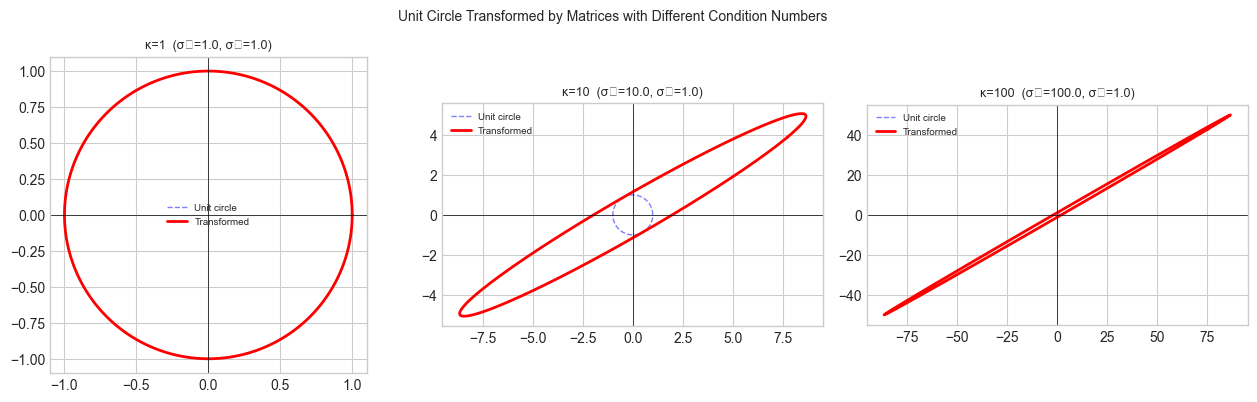

Higher κ → more eccentric ellipse → larger ratio of max to min stretching.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

# Visualize how a matrix transforms the unit circle
def transform_unit_circle(A, n_pts=200):
    theta = np.linspace(0, 2*np.pi, n_pts)
    circle = np.array([np.cos(theta), np.sin(theta)])  # (2, n_pts)
    ellipse = A @ circle  # (2, n_pts)
    return circle, ellipse

# Three 2x2 matrices with different condition numbers
kappa_vals = [1.0, 10.0, 100.0]
matrices = []
for kappa in kappa_vals:
    # Build matrix with singular values [kappa, 1] rotated 30 degrees
    angle = np.pi / 6
    R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    S = np.diag([kappa, 1.0])
    matrices.append(R @ S @ R.T)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, A, kappa in zip(axes, matrices, kappa_vals):
    circle, ellipse = transform_unit_circle(A)
    ax.plot(circle[0], circle[1], 'b--', lw=1, alpha=0.5, label='Unit circle')
    ax.plot(ellipse[0], ellipse[1], 'r-', lw=2, label='Transformed')
    sigma1, sigma2 = np.linalg.svd(A, compute_uv=False)[:2]
    ax.set_title(f'κ={kappa:.0f}  (σ₁={sigma1:.1f}, σ₂={sigma2:.1f})', fontsize=9)
    ax.set_aspect('equal')
    ax.legend(fontsize=7)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)

plt.suptitle('Unit Circle Transformed by Matrices with Different Condition Numbers', fontsize=10)
plt.tight_layout()
plt.show()
print('Higher κ → more eccentric ellipse → larger ratio of max to min stretching.')

## 4. Mathematical Formulation

**Common matrix norms** for $A \in \mathbb{R}^{m \times n}$ with singular values $\sigma_1 \geq \ldots \geq \sigma_r > 0$:

$$\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2} = \sqrt{\sum_i \sigma_i^2} \quad \text{(Frobenius)}$$
$$\|A\|_2 = \sigma_1 \quad \text{(spectral, induced by L2 vector norm)}$$
$$\|A\|_* = \sum_i \sigma_i \quad \text{(nuclear, sum of singular values)}$$

**Condition number** (spectral):
$$\kappa_2(A) = \frac{\sigma_1}{\sigma_n}$$

**Perturbation bound:** if $A(\mathbf{x} + \delta\mathbf{x}) = \mathbf{b} + \delta\mathbf{b}$, then:
$$\frac{\|\delta\mathbf{x}\|}{\|\mathbf{x}\|} \leq \kappa(A) \frac{\|\delta\mathbf{b}\|}{\|\mathbf{b}\|}$$
The condition number is the worst-case amplification factor for relative errors.

## 5. Python Implementation

In [3]:
def matrix_norms(A):
    """
    Compute Frobenius, spectral (L2), and nuclear norms.
    Args: A: (m, n) matrix
    Returns: dict of norm values
    """
    _, s, _ = np.linalg.svd(A, full_matrices=False)
    return {
        'frobenius': np.sqrt(np.sum(A**2)),       # sqrt(sum of squares)
        'frobenius_svd': np.sqrt(np.sum(s**2)),   # same via SVD
        'spectral': s[0],                          # largest singular value
        'nuclear': s.sum(),                         # sum of singular values
    }

def condition_number(A, tol=1e-15):
    """
    Spectral condition number κ₂(A) = σ_max / σ_min.
    Returns np.inf for singular/near-singular matrices.
    """
    _, s, _ = np.linalg.svd(A, full_matrices=False)
    if s[-1] < tol:
        return np.inf
    return s[0] / s[-1]

# Build a family of matrices with controlled condition numbers
for target_kappa in [1, 10, 100, 1000, 1e6]:
    # Use SVD to build a matrix with exactly this condition number
    U, _, Vt = np.linalg.svd(rng.normal(0, 1, (4, 4)), full_matrices=False)
    s_controlled = np.array([target_kappa, np.sqrt(target_kappa), np.sqrt(target_kappa), 1.0])
    A_test = U @ np.diag(s_controlled) @ Vt
    kappa_computed = condition_number(A_test)
    norms = matrix_norms(A_test)
    print(f'κ_target={target_kappa:.0e}  κ_computed={kappa_computed:.4e}  ||A||_F={norms["frobenius"]:.3f}  ||A||_2={norms["spectral"]:.3f}')

κ_target=1e+00  κ_computed=1.0000e+00  ||A||_F=2.000  ||A||_2=1.000
κ_target=1e+01  κ_computed=1.0000e+01  ||A||_F=11.000  ||A||_2=10.000
κ_target=1e+02  κ_computed=1.0000e+02  ||A||_F=101.000  ||A||_2=100.000
κ_target=1e+03  κ_computed=1.0000e+03  ||A||_F=1001.000  ||A||_2=1000.000
κ_target=1e+06  κ_computed=1.0000e+06  ||A||_F=1000001.000  ||A||_2=1000000.000


## 6. Experiments

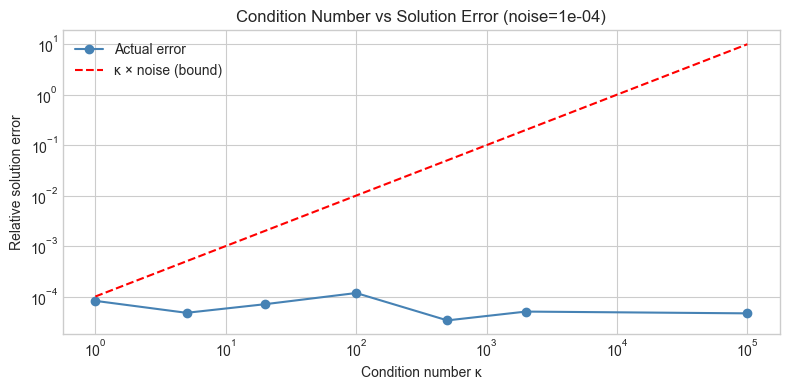

Error grows proportionally with κ — the condition number is a sensitivity multiplier.


In [4]:
# --- Experiment: Condition number vs numerical solution error ---
# Hypothesis: higher κ leads to larger solution error for perturbed RHS.
# Try changing: KAPPA_RANGE, NOISE_LEVEL

KAPPA_RANGE = [1, 5, 20, 100, 500, 2000, 1e5]
NOISE_LEVEL = 1e-4   # <-- try 1e-3, 1e-5

errors = []
for kappa in KAPPA_RANGE:
    # Build 4x4 matrix with condition number kappa
    U_e, _, Vt_e = np.linalg.svd(rng.normal(0, 1, (4, 4)), full_matrices=False)
    s_e = np.array([kappa, kappa**(2/3), kappa**(1/3), 1.0])
    A_e = U_e @ np.diag(s_e) @ Vt_e
    
    x_exact = rng.normal(0, 1, 4)
    b_exact = A_e @ x_exact
    b_noisy = b_exact + NOISE_LEVEL * rng.normal(0, 1, 4)
    
    x_exact_sol = np.linalg.solve(A_e, b_exact)
    x_noisy_sol = np.linalg.solve(A_e, b_noisy)
    
    rel_err = np.linalg.norm(x_noisy_sol - x_exact_sol) / np.linalg.norm(x_exact_sol)
    errors.append(rel_err)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(KAPPA_RANGE, errors, 'o-', ms=6, color='steelblue', label='Actual error')
ax.loglog(KAPPA_RANGE, [NOISE_LEVEL * k for k in KAPPA_RANGE], 'r--', lw=1.5, label='κ × noise (bound)')
ax.set_xlabel('Condition number κ')
ax.set_ylabel('Relative solution error')
ax.set_title(f'Condition Number vs Solution Error (noise={NOISE_LEVEL:.0e})')
ax.legend()
plt.tight_layout()
plt.show()
print('Error grows proportionally with κ — the condition number is a sensitivity multiplier.')

## 7. Exercises

**Easy 1.** For a $3 \times 3$ identity matrix, compute all three norms (Frobenius, spectral, nuclear). What are they? Why?

**Easy 2.** The Hilbert matrix $H_{ij} = 1/(i+j-1)$ is famously ill-conditioned. Compute its condition number for sizes $n = 4, 6, 8, 10$ and plot $\log(\kappa)$ vs $n$.

**Medium 1.** Implement a function that builds an $n \times n$ matrix with a specified condition number $\kappa$ using SVD (place singular values at geometric spacing from 1 to $\kappa$). Verify by computing the condition number of the result.

**Medium 2.** Show that $\|A\|_F \leq \sqrt{r} \|A\|_2$ where $r = \text{rank}(A)$. Verify this inequality for 100 random matrices of varying shape and rank.

**Hard.** The nuclear norm $\|A\|_* = \sum_i \sigma_i$ is convex in $A$. It is the convex relaxation of rank (since rank counts non-zeros and $\|\cdot\|_*$ sums them). Implement nuclear norm minimization via iterative soft-thresholding of singular values: $\text{shrink}(A, \lambda) = U \max(\Sigma - \lambda, 0) V^\top$. Apply this to low-rank matrix completion on a partially-observed matrix.

## 8. Mini Project

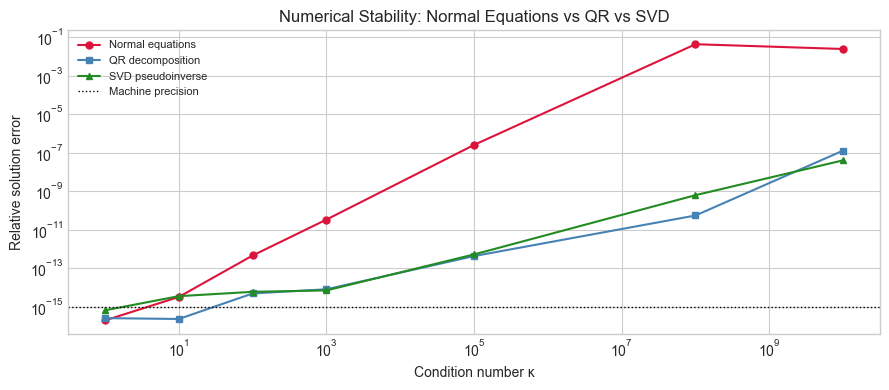

Normal equations square the condition number (κ(A.T A) = κ(A)²).
QR and SVD work at κ rather than κ², giving more reliable solutions.


In [5]:
# --- Mini Project: Numerical Stability Benchmark ---
# Compare three approaches to solving Ax=b on matrices with increasing κ.

def solve_normal_equations(A, b):
    """(A.T A)^{-1} A.T b — numerically unstable for large κ."""
    return np.linalg.solve(A.T @ A, A.T @ b)

def solve_qr(A, b):
    """QR decomposition: A = QR, x = R^{-1} Q.T b — more stable."""
    Q, R = np.linalg.qr(A)
    return np.linalg.solve(R, Q.T @ b)

def solve_svd(A, b, tol=1e-12):
    """Pseudoinverse via SVD — most stable."""
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    s_inv = np.where(s > tol, 1.0/s, 0.0)
    return Vt.T @ (s_inv * (U.T @ b))

kappas = [1, 10, 100, 1000, 1e5, 1e8, 1e10]
m, n = 20, 5

errs_ne, errs_qr, errs_svd = [], [], []

for kappa in kappas:
    U_b, _, Vt_b = np.linalg.svd(rng.normal(0, 1, (m, n)), full_matrices=False)
    s_b = np.geomspace(kappa, 1, n)
    A_b = U_b @ np.diag(s_b) @ Vt_b
    x_true = rng.normal(0, 1, n)
    b_b = A_b @ x_true
    
    for solver, errs in [(solve_normal_equations, errs_ne),
                         (solve_qr,              errs_qr),
                         (solve_svd,             errs_svd)]:
        try:
            x_sol = solver(A_b, b_b)
            errs.append(np.linalg.norm(x_sol - x_true) / np.linalg.norm(x_true))
        except Exception:
            errs.append(np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(kappas, errs_ne,  'o-', ms=5, color='crimson',    label='Normal equations')
ax.loglog(kappas, errs_qr,  's-', ms=5, color='steelblue',  label='QR decomposition')
ax.loglog(kappas, errs_svd, '^-', ms=5, color='forestgreen', label='SVD pseudoinverse')
ax.axhline(1e-15, color='black', ls=':', lw=1, label='Machine precision')
ax.set_xlabel('Condition number κ')
ax.set_ylabel('Relative solution error')
ax.set_title('Numerical Stability: Normal Equations vs QR vs SVD')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print('Normal equations square the condition number (κ(A.T A) = κ(A)²).')
print('QR and SVD work at κ rather than κ², giving more reliable solutions.')

## 9. Chapter Summary & Connections

- Matrix norms measure the size of linear maps: Frobenius = RMS of all entries; spectral = max singular value; nuclear = sum of singular values *(ch173)*.
- The condition number $\kappa_2(A) = \sigma_1/\sigma_n$ measures numerical sensitivity: a relative perturbation of size $\epsilon$ in $\mathbf{b}$ can produce a relative error of up to $\kappa \epsilon$ in $\mathbf{x}$.
- Squaring the matrix via normal equations squares the condition number. Prefer QR or SVD for numerical linear algebra.
- Nuclear norm minimization is the standard convex relaxation of rank-minimization, used in matrix completion and low-rank recovery problems.

**Forward:** Condition numbers reappear in ch212 (Gradient Descent) as the convergence rate of gradient descent on a quadratic depends on $\kappa(H)$ where $H$ is the Hessian. Ill-conditioned quadratics require many more iterations. Nuclear norm appears in ch289 (collaborative filtering) as a regularizer for low-rank matrix completion.

**Backward:** This chapter makes precise the numerical warnings in ch179 (Numerical Linear Algebra in Practice), which cautioned against taking explicit inverses. The relationship $\kappa = \sigma_1/\sigma_n$ depends entirely on ch173 (SVD).